Group Project: Matthew Peters, Ruby Mayrose, Xingyu Liu

# Part 2:

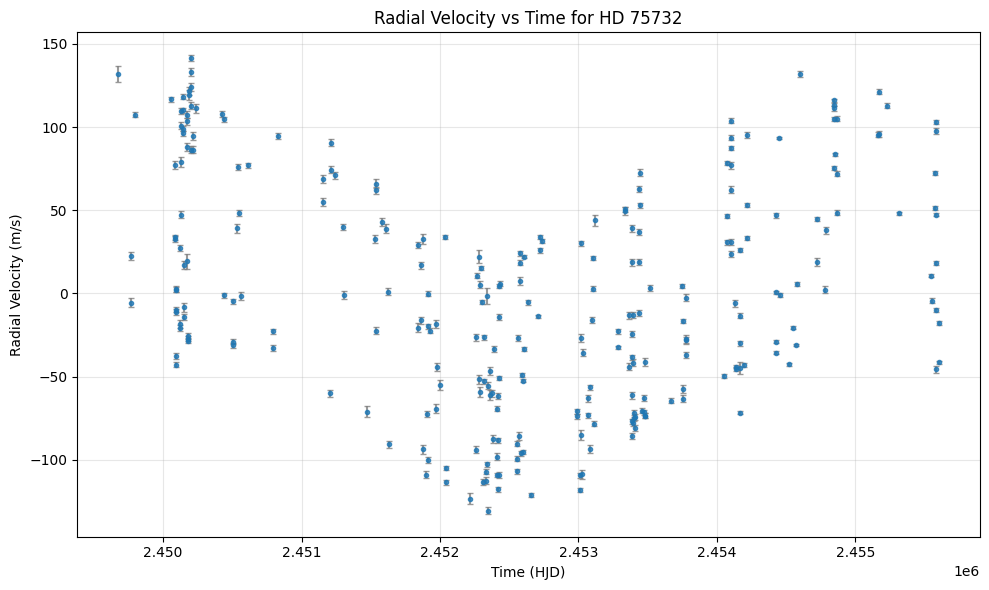

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii

# Load the data table
data = ascii.read("RadialVelocity.txt")

# Extract columns
time = data["HJD"]
rv = data["Radial_Velocity"]
rv_err = data["Radial_Velocity_Uncertainty"]

# Make plot
plt.figure(figsize=(10,6))
plt.errorbar(time, rv, yerr=rv_err, fmt='o', markersize=3, 
             ecolor='gray', capsize=2, alpha=0.8)

plt.xlabel("Time (HJD)")
plt.ylabel("Radial Velocity (m/s)")
plt.title("Radial Velocity vs Time for HD 75732")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Part 3:

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii
from scipy import optimize

In [6]:
data = ascii.read("RadialVelocity.txt")

time = data["HJD"]
rv = data["Radial_Velocity"]
rv_err = data["Radial_Velocity_Uncertainty"]

In [7]:
def rv_model(t, a, b, c, d):
    return a * np.sin(2*np.pi*(t - b)/c) + d

In [8]:
guess_params = [100, 0, 3000, 0]  # amplitude, phase, period, offset

In [9]:
best_params, covariance = optimize.curve_fit(
    rv_model, time, rv, p0=guess_params, sigma=rv_err, absolute_sigma=True
)

best_a, best_b, best_c, best_d = best_params

print("Best-fit parameters:")
print("Amplitude =", best_a)
print("Phase shift =", best_b)
print("Period =", best_c)
print("Mean RV =", best_d)

Best-fit parameters:
Amplitude = 47.91814842467463
Phase shift = -1478158.6052357587
Period = 4806.915133562828
Mean RV = -1.418465396827657


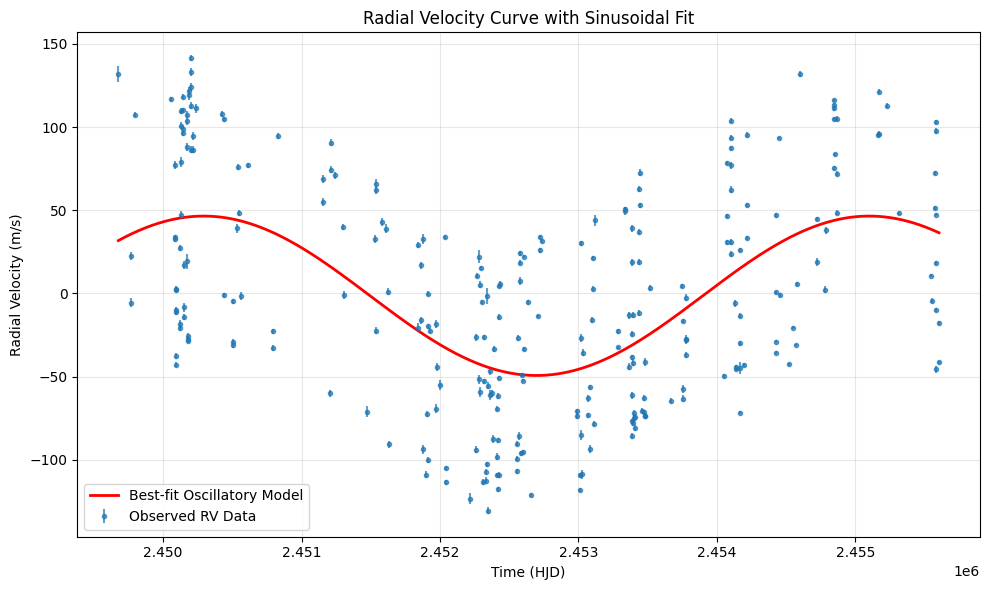

In [10]:
t_fit = np.linspace(min(time), max(time), 1000)
rv_fit = rv_model(t_fit, best_a, best_b, best_c, best_d)

plt.figure(figsize=(10,6))
plt.errorbar(time, rv, yerr=rv_err, fmt='o', markersize=3, 
             alpha=0.7, label="Observed RV Data")

plt.plot(t_fit, rv_fit, 'r-', linewidth=2, label="Best-fit Oscillatory Model")

plt.xlabel("Time (HJD)")
plt.ylabel("Radial Velocity (m/s)")
plt.title("Radial Velocity Curve with Sinusoidal Fit")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Part 4:

Best-fit parameters:
Amplitude = 47.91814842467463
Phase shift = -1478158.6052357587
Period = 4806.915133562828
Mean RV = -1.418465396827657


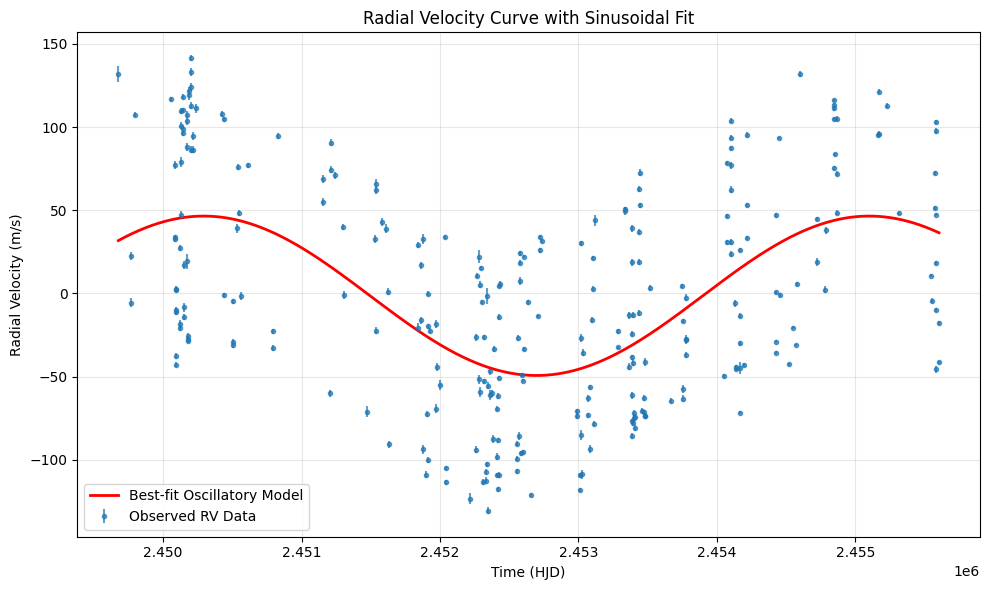

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii
from scipy import optimize

data = ascii.read("RadialVelocity.txt")

time = data["HJD"]
rv = data["Radial_Velocity"]
rv_err = data["Radial_Velocity_Uncertainty"]

def rv_model(t, a, b, c, d):
    return a * np.sin(2*np.pi*(t - b)/c) + d

guess_params = [100, 0, 3000, 0]  # amplitude, phase, period, offset

best_params, covariance = optimize.curve_fit(
    rv_model, time, rv, p0=guess_params, sigma=rv_err, absolute_sigma=True
)

best_a, best_b, best_c, best_d = best_params

print("Best-fit parameters:")
print("Amplitude =", best_a)
print("Phase shift =", best_b)
print("Period =", best_c)
print("Mean RV =", best_d)

t_fit = np.linspace(min(time), max(time), 1000)
rv_fit = rv_model(t_fit, best_a, best_b, best_c, best_d)

plt.figure(figsize=(10,6))
plt.errorbar(time, rv, yerr=rv_err, fmt='o', markersize=3, 
             alpha=0.7, label="Observed RV Data")

plt.plot(t_fit, rv_fit, 'r-', linewidth=2, label="Best-fit Oscillatory Model")

plt.xlabel("Time (HJD)")
plt.ylabel("Radial Velocity (m/s)")
plt.title("Radial Velocity Curve with Sinusoidal Fit")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

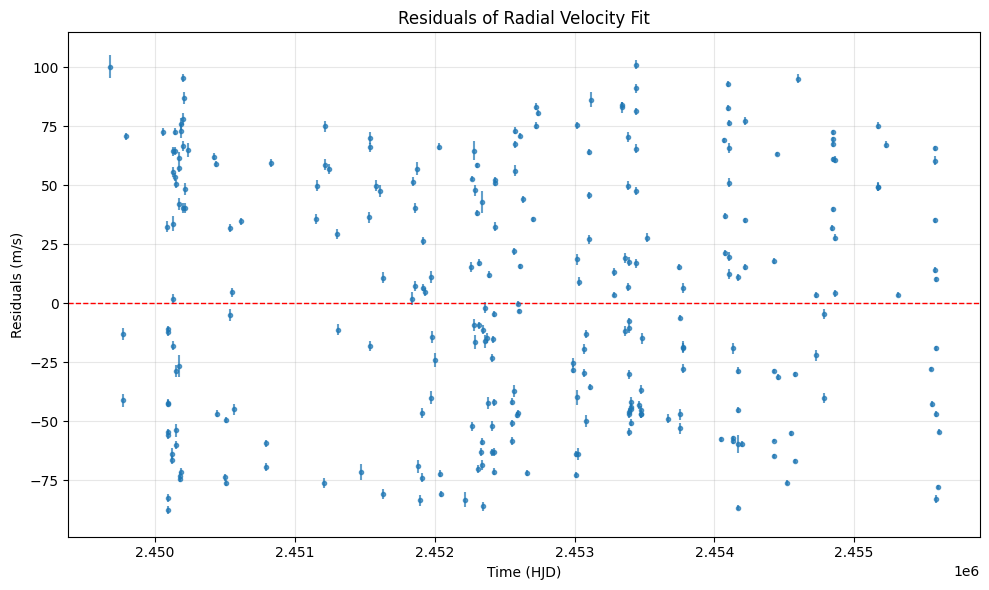

In [12]:
residuals = rv - rv_model(time, best_a, best_b, best_c, best_d)

plt.figure(figsize=(10,6))
plt.errorbar(time, residuals, yerr=rv_err, fmt='o', markersize=3, alpha=0.7)
plt.axhline(0, color='r', linestyle='--', linewidth=1)
plt.xlabel("Time (HJD)")
plt.ylabel("Residuals (m/s)")
plt.title("Residuals of Radial Velocity Fit")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

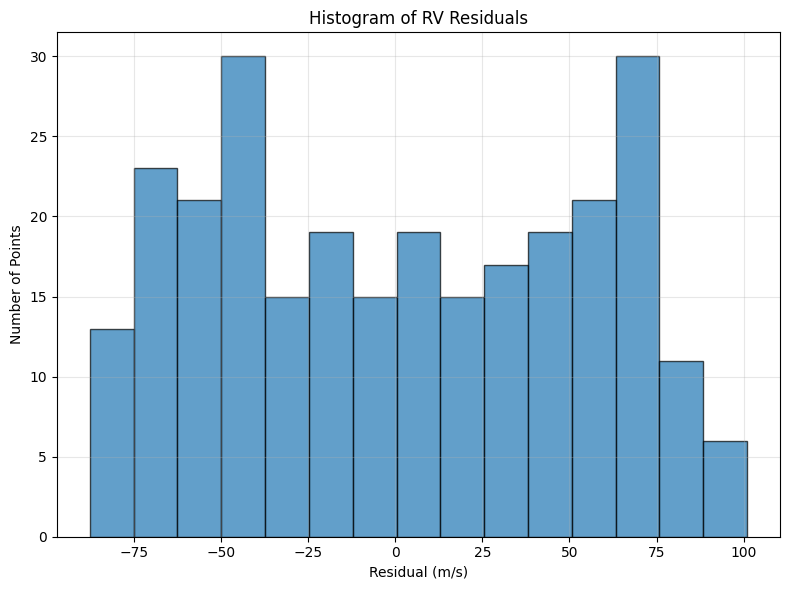

Standard deviation of residuals: 52.21 m/s
Typical measurement error: 1.81 m/s


In [13]:
plt.figure(figsize=(8,6))
plt.hist(residuals, bins=15, edgecolor='k', alpha=0.7)
plt.xlabel("Residual (m/s)")
plt.ylabel("Number of Points")
plt.title("Histogram of RV Residuals")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

residual_std = np.std(residuals)
print(f"Standard deviation of residuals: {residual_std:.2f} m/s")
print(f"Typical measurement error: {np.mean(rv_err):.2f} m/s")

# Part 5:

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii
from scipy import optimize

amplitudek=best_a
periodp=best_c
smassofsun=(1.015+0.905+0.97470756317)/3
mexoplanet=(amplitudek/28.4)*((periodp/365)**(1/3))*(smassofsun)**(2/3)
print("the mass of the exoplanet is", mexoplanet, "times of the mass of Jupiter")
print("This exoplanet is 55 Cnc d")

the mass of the exoplanet is 3.8907068761059804 times of the mass of Jupiter
This exoplanet is 55 Cnc d
